In [1]:
import sympy as sp
import sympy.diffgeom as dg

import numpy as np

import matplotlib.pyplot as plt

import scipy.integrate as sint

In [2]:
state_mfld = dg.Manifold("M", 5)
state_mfld_patch = dg.Patch("P", state_mfld)

x, y, theta, v, omega = sp.symbols(r"x,y,\theta,v,\omega", real=True)

state_mfld_coords = dg.CoordSystem(
    "StateSpace", state_mfld_patch, (x, y, theta, v, omega)
)

(x_sc, y_sc, theta_sc, v_sc, omega_sc) = state_mfld_coords.base_scalars()
(x_vec, y_vec, theta_vec, v_vec, omega_vec) = state_mfld_coords.base_vectors()

f = (
    v_sc * sp.cos(theta_sc) * x_vec
    + v_sc * sp.sin(theta_sc) * y_vec
    + omega_sc * theta_vec
)

f1 = v_vec
f2 = omega_vec

display(f, f1, f2)

sin(\theta)*v*e_y + cos(\theta)*v*e_x + \omega*e_\theta

e_v

e_\omega

This is the original form of the equations to calculate the constrained Christoffel symbols and do not work.

$$\dot{y}^i(t)\dot{y}^j(t) \overset{\mathcal{D}}{\Gamma_{ik}^k} = -\sum_{l=1}^{n}{\frac{\partial f^k}{\partial y^l(t)}}\dot{y}_l(t)$$

$$c_{ij}^k = \overset{\mathcal{D}}{\Gamma_{ik}^k}, v = \begin{bmatrix} \dot{y}^1 \\ \vdots \\ \dot{y}^n\end{bmatrix}, \quad C^k = \left(-\sum_{l=1}^n{\frac{\partial f^k}{\partial y^l(t)}}\dot{y}_l(t)\right)(v v^T)^{-1}$$

In [ ]:
# f_coeffs = [f.coeff(v) for v in state_mfld_coords.base_vectors()]
# display(f_coeffs)

# v = sp.Matrix(f_coeffs)  # alternate notation
# display(v)

# # theta_vec(f_coeffs[0])  # "derivative" due to diffgeom shenanigans
# f_coeffs_jacob = [
#     [v(coeff) for v in state_mfld_coords.base_vectors()] for coeff in f_coeffs
# ]
# display(f_coeffs_jacob)

# v_mat: sp.Matrix = v @ v.T
# v_mat_pinv = sp.simplify(v_mat.pinv())

# display(v_mat)
# display(v_mat_pinv)
# display(sp.simplify(v_mat_pinv @ v_mat))


# for i in range(5):
#     f_coeffs = sum(df_dyi * dyi_dt for df_dyi, dyi_dt in zip(f_coeffs_jacob[i], v))
#     print(f_coeffs)


# def gen_christoffels_from_tbundle_curve(curve, basis_vecs):
#     f = [curve.coeff(v) for v in basis_vecs]
#     f_partials = [[vec(coeff) for vec in basis_vecs] for coeff in f]

#     # invert the matrix
#     v = sp.Matrix(f)
#     v_mat: sp.Matrix = v @ v.T

#     display(v_mat[:3,:3].inv())

#     return
#     v_rows, v_cols = (v_mat.rref(), v_mat.T.rref()[1])

#     v_mat_extract = v_mat.extract(v_rows, v_cols)
#     print(f"rows: {v_rows}")
#     display(v_mat_extract)

# # unable to get this to work
# gen_christoffels_from_tbundle_curve(f, state_mfld_coords.base_vectors())

The next equation I tested out was the following. This equation was approximate but I noticed that if I increase the simulation time then it would be oscillatory but would trace out a larger path in the same circle (although would look like a much larger flower looking shape). Therefore I tried increasing the gain by a constant and the circle radius went down. This then sent me on a wild goose chase as I thought I was missing a component in trying to find a $v^T M v = 0$ that increases the magnitude fo the symbols. However, this just led to more problems.
$$C^k = \frac{Bv}{||v||^4}{vv^T}$$

I thought that there might be a form that admitted slightly larger long-term stability of the geodesics but unfortunately this is just not the case. I eventually just gave up and computed the full expansion of a possible $C^k$ into symmetric and skew components and I was able to come up with a final equation using the fact that the solution to $x^T A x + Bx = 0$ is $S = 0.5(A+A^T)$, $x = -1/2S^{-1}B^T$

In [3]:
def gen_christoffels_from_tbundle_curve(curve_dg, basis_vecs):
    f = [curve_dg.coeff(v) for v in basis_vecs]
    f_partials = sp.Matrix([[vec(coeff) for vec in basis_vecs] for coeff in f])

    # invert the matrix
    v: sp.Matrix = sp.Matrix(f)
    u = v / v.norm()

    n = len(f)
    christoffels = sp.MutableDenseNDimArray.zeros(n, n, n)

    for k in range(n):
        # display((v @ v.T @ v @ v.T)[0:3,0:3].pinv())
        # return

        def pinv_block(block):
            sub = block[0:3,0:3]
            block[0:3,0:3] = sub.pinv()
            return block
        
        b_mat = f_partials[k, :]
        
        c_mat = (
            - (b_mat @ v)[0] * (v @ v.T).pinv()
        )

        christoffels[:, :, k] = c_mat

        # display(c_mat)

    return christoffels


# constrained christoffel symbols
christoffels = gen_christoffels_from_tbundle_curve(f, state_mfld_coords.base_vectors())
display(christoffels)

[[[sin(\theta)*cos(conjugate(\theta))**3*cos(\theta)*conjugate(v)**3*v**2*\omega/((sin(conjugate(\theta))*sin(\theta)*conjugate(v)*v + cos(conjugate(\theta))*cos(\theta)*conjugate(v)*v + conjugate(\omega)*\omega)*(sin(conjugate(\theta))*sin(\theta)*cos(conjugate(\theta))*cos(\theta)*conjugate(v)**2*v**2 + cos(conjugate(\theta))**2*cos(\theta)**2*conjugate(v)**2*v**2 + cos(conjugate(\theta))*cos(\theta)*conjugate(v)*conjugate(\omega)*v*\omega)), -cos(conjugate(\theta))**3*cos(\theta)**2*conjugate(v)**3*v**2*\omega/((sin(conjugate(\theta))*sin(\theta)*conjugate(v)*v + cos(conjugate(\theta))*cos(\theta)*conjugate(v)*v + conjugate(\omega)*\omega)*(sin(conjugate(\theta))*sin(\theta)*cos(conjugate(\theta))*cos(\theta)*conjugate(v)**2*v**2 + cos(conjugate(\theta))**2*cos(\theta)**2*conjugate(v)**2*v**2 + cos(conjugate(\theta))*cos(\theta)*conjugate(v)*conjugate(\omega)*v*\omega)), 0, 0, 0], [sin(conjugate(\theta))*sin(\theta)*cos(conjugate(\theta))**2*cos(\theta)*conjugate(v)**3*v**2*\omega/(

In [476]:
christoffels[2,2,0]

sin(\theta)*cos(conjugate(\theta))*cos(\theta)*conjugate(v)*conjugate(\omega)**2*v**2*\omega/((sin(conjugate(\theta))*sin(\theta)*conjugate(v)*v + cos(conjugate(\theta))*cos(\theta)*conjugate(v)*v + conjugate(\omega)*\omega)*(sin(conjugate(\theta))*sin(\theta)*cos(conjugate(\theta))*cos(\theta)*conjugate(v)**2*v**2 + cos(conjugate(\theta))**2*cos(\theta)**2*conjugate(v)**2*v**2 + cos(conjugate(\theta))*cos(\theta)*conjugate(v)*conjugate(\omega)*v*\omega))

In [4]:
christoffel_symbs = sp.simplify(
    christoffels.applyfunc(
        lambda e: e.subs(x_sc, x)
        .subs(y_sc, y)
        .subs(theta_sc, theta)
        .subs(v_sc, v)
        .subs(omega_sc, omega)
    )
)
display(christoffel_symbs)


def eval_christoffels(x_curr):
    vals = np.array(
        [
            sp.lambdify((x, y, theta, v, omega), e)(*x_curr)
            for e in list(christoffel_symbs)
        ]
    )
    return vals.reshape(christoffel_symbs.shape)

[[[\omega*v**3*sin(\theta)*cos(\theta)**2/(\omega**2 + v**2)**2, -\omega*v**3*cos(\theta)**3/(\omega**2 + v**2)**2, 0, 0, 0], [\omega*v**3*sin(\theta)**2*cos(\theta)/(\omega**2 + v**2)**2, -\omega*v**3*sin(\theta)*cos(\theta)**2/(\omega**2 + v**2)**2, 0, 0, 0], [\omega**2*v**2*sin(2*\theta)/(2*(\omega**2 + v**2)**2), -\omega**2*v**2*cos(\theta)**2/(\omega**2 + v**2)**2, 0, 0, 0], [0, 0, 0, 0, 0], [0, 0, 0, 0, 0]], [[\omega*v**3*sin(\theta)**2*cos(\theta)/(\omega**2 + v**2)**2, -\omega*v**3*sin(\theta)*cos(\theta)**2/(\omega**2 + v**2)**2, 0, 0, 0], [\omega*v**3*sin(\theta)**3/(\omega**2 + v**2)**2, -\omega*v**3*sin(\theta)**2*cos(\theta)/(\omega**2 + v**2)**2, 0, 0, 0], [\omega**2*v**2*sin(\theta)**2/(\omega**2 + v**2)**2, -\omega**2*v**2*sin(2*\theta)/(2*(\omega**2 + v**2)**2), 0, 0, 0], [0, 0, 0, 0, 0], [0, 0, 0, 0, 0]], [[\omega**2*v**2*sin(2*\theta)/(2*(\omega**2 + v**2)**2), -\omega**2*v**2*cos(\theta)**2/(\omega**2 + v**2)**2, 0, 0, 0], [\omega**2*v**2*sin(\theta)**2/(\omega**2 +

In [5]:
# now test to ensure that integral curve and the geodesic under the constrained
# christoffel symbols are the same (ensuring this equation is correct)

x0 = [0.3, 0.6, -0.1, 1.0, -0.3]
tf = 4.0

t = np.linspace(0, tf, 100)


def unicycle_f(t, y):
    x, y, theta, v, omega = y
    return np.array([v * np.cos(theta), v * np.sin(theta), omega, 0.0, 0.0])


# solve as an integral curve on TQ
curve_result = sint.solve_ivp(unicycle_f, [0.0, tf], x0, t_eval=t[1:-1])
curve_path = curve_result.y.T  # turns it to each time sample on rows

# solve as the geodesics on Q

v0 = unicycle_f(0.0, x0)

n = 5


# def lambdify_tensor(t: sp.Array, args):
#     shape = t.shape
#     elems = list(t)

#     elem_callables = [sp.lambdify(args, e) for e in elems]

#     def tensor_callable(x):
#         x_args = [x[i] for i in range(len(args))]
#         values = [e(*x_args) for e in elem_callables]

#         return np.array(values).reshape(shape)

#     return tensor_callable


# display(eval_christoffels(x0))
# display(eval_christoffels(2*x0))
# break


def geodesic_f(t, y):
    x = y[:n]
    v = y[n:]

    dot_x = v
    dot_v = np.zeros((n,))

    curr_christoffels = eval_christoffels(x)
    for k in range(n):
        for i, j in zip(range(n), range(n)):
            dot_v[k] += -v[i] * v[j] * curr_christoffels[i, j, k]

    return np.concat((dot_x, dot_v))


geodesic_result = sint.solve_ivp(
    geodesic_f, [0.0, tf], np.concat([x0, v0]), t_eval=t[1:-1], method=sint.Radau
)
geodesic_path = geodesic_result.y.T  # turns it to each time sample on rows

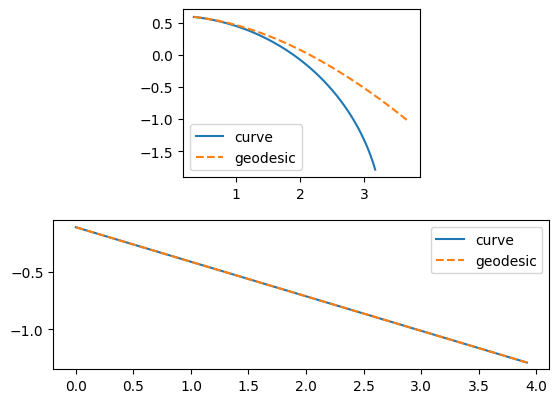

In [6]:

# generate all the plots

fig, (ax1, ax2) = plt.subplots((2))

ax1.plot(curve_path[:, 0], curve_path[:, 1], label="curve")
ax1.plot(geodesic_path[:, 0], geodesic_path[:, 1], "--", label="geodesic")
ax1.set_aspect("equal")

# ax1.axhline(y=0, color='k')
# ax1.axvline(x=0, color='k')

ax2.plot(t[:curve_path.shape[0]], curve_path[:, 2], label="curve")
ax2.plot(t[:geodesic_path.shape[0]], geodesic_path[:, 2], "--", label="geodesic")
ax2.set_aspect("equal")

# ax2.axhline(y=0, color='k')
# ax2.axvline(x=0, color='k')

ax1.legend()
ax2.legend()

So obviously it does not hold for long range duration likely due to the use of the `pinv` instead of permitting use of a regular `inv`. Although not a problem with this example it is possible that a distribution that changes discontinuously will not even have a smooth solution so this would need to be computed at each location anyways. Therefore there is decent adherence to the actual system trajectory at the initial point but there is divergence over a long-term integration. The following will test to ensure that this does show local adherence by checking the generated geodesics along a couple of paths starting at intervals along the integral curve.

In [7]:
x0 = [0.3, 0.6, -0.1, 1.0, -0.3]
tf = 10.0

num_samples = 1000

t = np.linspace(0, tf, num_samples)

print("Generating integral curve...")

# solve as an integral curve on TQ
curve_result = sint.solve_ivp(unicycle_f, [0.0, tf], x0, t_eval=t)
curve_path = curve_result.y.T  # turns it to each time sample on rows

# choose a couple points along the integral curve

geodesic_start_idxs = [
    0,
    int(curve_path.shape[0] * 1 / 3),
    int(curve_path.shape[0] * 2 / 3),
]

print("Generating geodesic paths...")

geodesic_paths = []
geodesic_tf = 3.0
geodesic_t = np.linspace(0, geodesic_tf, 1000)
for i in range(len(geodesic_start_idxs)):
    print(f"Geodesic: {i}")

    start_idx = geodesic_start_idxs[i]

    geodesic_x0 = np.array(
        [*curve_path[start_idx], *unicycle_f(t[start_idx], curve_path[start_idx])]
    )
    geodesic_result = sint.solve_ivp(
        geodesic_f,
        [t[start_idx], t[start_idx] + geodesic_tf],
        geodesic_x0,
        t_eval=geodesic_t + t[start_idx],
        method=sint.Radau,
    )

    geodesic_paths.append((geodesic_result.t, geodesic_result.y.T))

Generating integral curve...
Generating geodesic paths...
Geodesic: 0
Geodesic: 1
Geodesic: 2


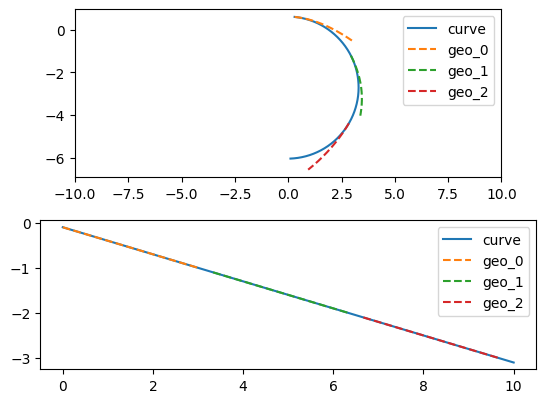

In [500]:
fig, (ax1, ax2) = plt.subplots((2))

ax1.plot(curve_path[:, 0], curve_path[:, 1], label="curve")
ax1.set_aspect("equal")
ax1.set_xlim(-10.0, 10.0)

ax2.plot(t[: curve_path.shape[0]], curve_path[:, 2], label="curve")
ax2.set_aspect("equal")

for i in range(len(geodesic_paths)):
    geo_t, geo_y = geodesic_paths[i]

    ax1.plot(geo_y[:, 0], geo_y[:, 1], "--", label=f"geo_{i}")  # position
    ax2.plot(geo_t, geo_y[:, 2], "--", label=f"geo_{i}")  # angle

ax1.legend()
ax2.legend()